<a href="https://colab.research.google.com/github/hj245668/ds6_warpUp/blob/main/20251031_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

현 시세


,현재가
기업명,
Krafton,276000
NCSoft,221250
NexonGames,13400
Wemade,26700
Com2us,34150
PearlAbyss,34600


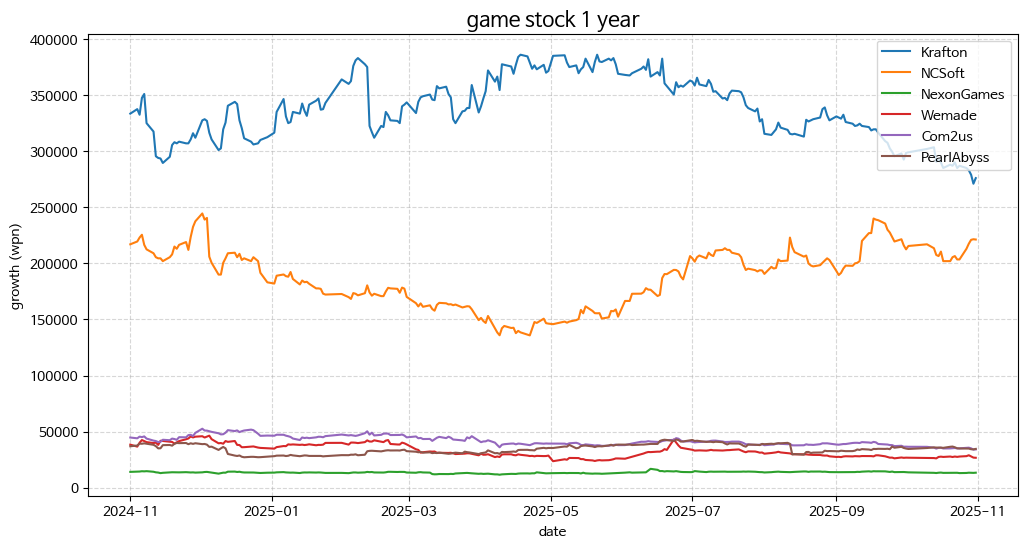

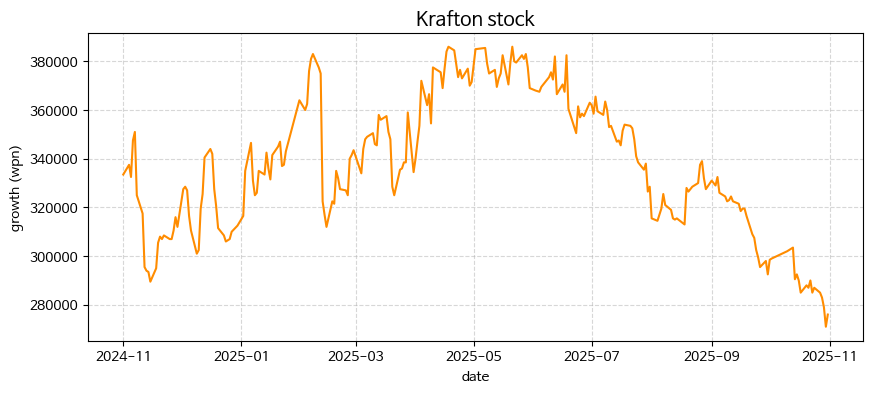

In [25]:


!pip install finance-datareader yfinance matplotlib --quiet

import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt

codes = {
    'Krafton':'259960',
    'NCSoft':'036570',
    'NexonGames':'225570',
    'Wemade':'112040',
    'Com2us':'078340',
    'PearlAbyss':'263750'
}

start = dt.datetime.now() - dt.timedelta(days=365)
end = dt.datetime.now()

price_data = {}
for name, code in codes.items():
    df = fdr.DataReader(code, start, end)
    price_data[name] = df

latest_prices = {name: df['Close'].iloc[-1] for name, df in price_data.items()}
latest_df = pd.DataFrame.from_dict(latest_prices, orient='index', columns=['현재가'])
latest_df.index.name = '기업명'
print("현 시세")
display(latest_df)

plt.figure(figsize=(12,6))
for name, df in price_data.items():
    plt.plot(df.index, df['Close'], label=name)

plt.title('game stock 1 year', fontsize=15)
plt.xlabel('date')
plt.ylabel('growth (wpn)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(price_data['Krafton'].index, price_data['Krafton']['Close'], color='darkorange')
plt.title('Krafton stock', fontsize=14)
plt.xlabel('date')
plt.ylabel('growth (wpn)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [5]:
!pip install finance-datareader --quiet

import FinanceDataReader as fdr
import pandas as pd
import datetime as dt

codes = {
    'Krafton':'259960',
    'NCSoft':'036570',
    'NexonGames':'225570',
    'Wemade':'112040',
    'Com2us':'078340',
    'PearlAbyss':'263750'
}

start = dt.datetime.now() - dt.timedelta(days=5*365)
end = dt.datetime.now()

summary_data = []

for name, code in codes.items():
    df = fdr.DataReader(code, start, end)
    max_price = df['Close'].max()
    current_price = df['Close'].iloc[-1]
    ratio = round((current_price / max_price) * 100, 2)
    max_date = df['Close'].idxmax().strftime('%Y-%m-%d')
    summary_data.append({
        '기업명': name,
        '현재가(원)': round(current_price, 1),
        '5년내 최고가(원)': round(max_price, 1),
        '최고가 기준일': max_date,
        '현재가/최고가(%)': ratio
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('현재가/최고가(%)', ascending=False).reset_index(drop=True)

display(summary_df)


,기업명,현재가(원),5년내 최고가(원),최고가 기준일,현재가/최고가(%)
0,Krafton,276500,567000,2021-11-17,48.77
1,NexonGames,13360,29350,2024-08-07,45.52
2,PearlAbyss,34550,141000,2021-11-17,24.50
3,NCSoft,221000,1038000,2021-02-08,21.29
4,Com2us,34250,177600,2021-04-12,19.28
5,Wemade,26750,237000,2021-11-19,11.29


In [6]:
!pip install finance-datareader --quiet

import FinanceDataReader as fdr
import pandas as pd
import datetime as dt

codes = {
    'Krafton':'259960',
    'NCSoft':'036570',
    'NexonGames':'225570',
    'Wemade':'112040',
    'Com2us':'078340',
    'PearlAbyss':'263750'
}

start = dt.datetime.now() - dt.timedelta(days=5*365)
end = dt.datetime.now()

summary_data = []

for name, code in codes.items():
    df = fdr.DataReader(code, start, end)
    max_price = df['Close'].max()
    current_price = df['Close'].iloc[-1]
    ratio = round((current_price / max_price) * 100, 2)
    gap = round(max_price - current_price, 1)
    max_date = df['Close'].idxmax().strftime('%Y-%m-%d')
    summary_data.append({
        '기업명': name,
        '현재가(원)': round(current_price, 1),
        '5년내 최고가(원)': round(max_price, 1),
        '최고가 기준일': max_date,
        'Gap(원)': gap,
        '현재가/최고가(%)': ratio
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('현재가/최고가(%)', ascending=False).reset_index(drop=True)

display(summary_df)


,기업명,현재가(원),5년내 최고가(원),최고가 기준일,Gap(원),현재가/최고가(%)
0,Krafton,276500,567000,2021-11-17,290500,48.77
1,NexonGames,13360,29350,2024-08-07,15990,45.52
2,PearlAbyss,34550,141000,2021-11-17,106450,24.50
3,NCSoft,221000,1038000,2021-02-08,817000,21.29
4,Com2us,34250,177600,2021-04-12,143350,19.28
5,Wemade,26750,237000,2021-11-19,210250,11.29


In [7]:
# 우리기술 티커 032820

!pip install finance-datareader --quiet

import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

code = '032820'  # 우리기술
start = dt.datetime.now() - dt.timedelta(days=5*365)
end = dt.datetime.now()

df = fdr.DataReader(code, start, end).copy()
df = df[['Open','High','Low','Close','Volume']].dropna()

df['MA20'] = df['Close'].rolling(20).mean()
df['MA60'] = df['Close'].rolling(60).mean()
df['MA120'] = df['Close'].rolling(120).mean()

current_price = float(df['Close'].iloc[-1])
max_5y = float(df['Close'].max())
min_5y = float(df['Close'].min())
date_max_5y = df['Close'].idxmax().strftime('%Y-%m-%d')
date_min_5y = df['Close'].idxmin().strftime('%Y-%m-%d')

last_252 = df.tail(252)
max_52w = float(last_252['Close'].max())
min_52w = float(last_252['Close'].min())
date_max_52w = last_252['Close'].idxmax().strftime('%Y-%m-%d')
date_min_52w = last_252['Close'].idxmin().strftime('%Y-%m-%d')

gap_5y = round(max_5y - current_price, 1)
ratio_5y = round(current_price / max_5y * 100, 2)
gap_52w = round(max_52w - current_price, 1)
ratio_52w = round(current_price / max_52w * 100, 2)

vol_ma20 = df['Volume'].rolling(20).mean()

summary = pd.DataFrame([{
    '종목': '우리기술(032820)',
    '현재가(원)': round(current_price, 1),
    '5년내 최고가(원)': round(max_5y, 1),
    '5년 최고가 기준일': date_max_5y,
    'Gap_5Y(원)': gap_5y,
    '현재가/5년최고(%)': ratio_5y,
    '52주 최고가(원)': round(max_52w, 1),
    '52주 최고가 기준일': date_max_52w,
    'Gap_52W(원)': gap_52w,
    '현재가/52주최고(%)': ratio_52w,
    '5년내 최저가(원)': round(min_5y, 1),
    '5년 최저가 기준일': date_min_5y,
    '52주 최저가(원)': round(min_52w, 1),
    '52주 최저가 기준일': date_min_52w
}])

summary


,종목,현재가(원),5년내 최고가(원),5년 최고가 기준일,Gap_5Y(원),현재가/5년최고(%),52주 최고가(원),52주 최고가 기준일,Gap_52W(원),현재가/52주최고(%),5년내 최저가(원),5년 최저가 기준일,52주 최저가(원),52주 최저가 기준일
0,우리기술(032820),4895.0,5240.0,2025-10-30,345.0,93.42,5240.0,2025-10-30,345.0,93.42,1105.0,2021-01-29,1555.0,2025-04-09


/tmp/ipython-input-3573391761.py:8: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.grid(True); plt.legend(); plt.tight_layout()
/tmp/ipython-input-3573391761.py:8: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.grid(True); plt.legend(); plt.tight_layout()
/tmp/ipython-input-3573391761.py:8: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.grid(True); plt.legend(); plt.tight_layout()
/tmp/ipython-input-3573391761.py:8: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.grid(True); plt.legend(); plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI

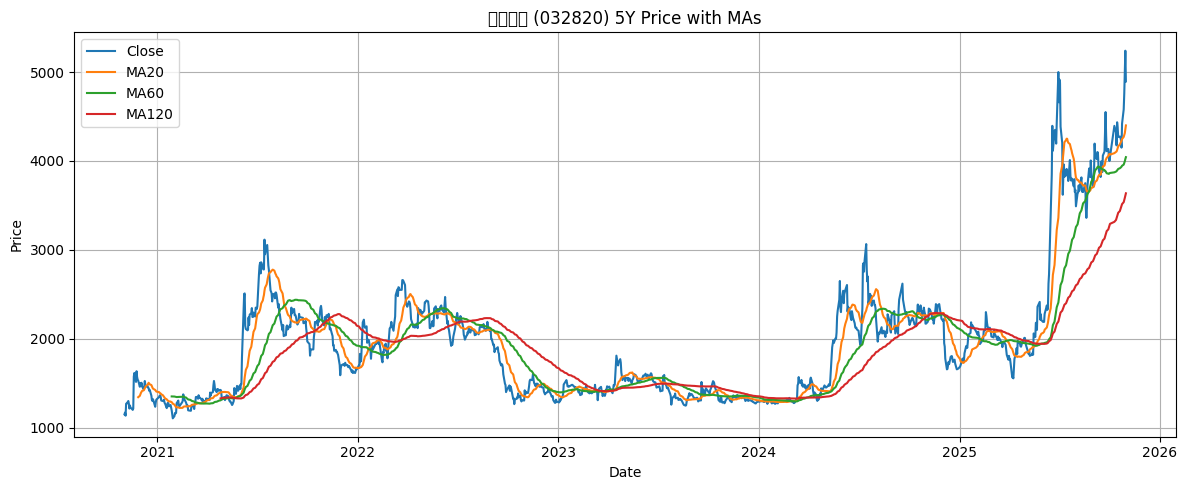

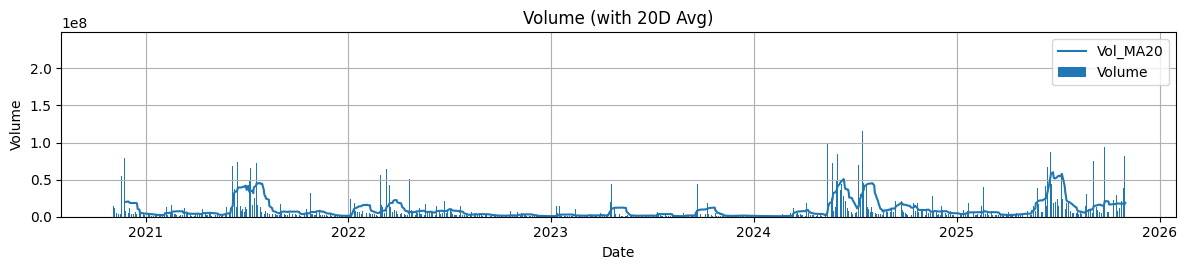

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['MA20'], label='MA20')
plt.plot(df.index, df['MA60'], label='MA60')
plt.plot(df.index, df['MA120'], label='MA120')
plt.title('우리기술 (032820) 5Y Price with MAs')
plt.xlabel('Date'); plt.ylabel('Price')
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,2.8))
plt.bar(df.index, df['Volume'], label='Volume')
plt.plot(df.index, vol_ma20, label='Vol_MA20')
plt.title('Volume (with 20D Avg)')
plt.xlabel('Date'); plt.ylabel('Volume')
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


In [26]:
!pip install pykrx finance-datareader --quiet

import pandas as pd
import numpy as np
from datetime import datetime
from pykrx import stock
import FinanceDataReader as fdr

tickers = {
    "Krafton":"259960",
    "NCSOFT":"036570",
    "NexonGames":"225570",
    "Wemade":"112040",
    "Com2us":"078340",
    "PearlAbyss":"263750"
}

start = "2024-01-01"
end = datetime.now().strftime("%Y-%m-%d")

def get_shares(code):
    try:
        df = fdr.StockListing("KRX")
        s = df.loc[df["Code"]==code, "Shares"]
        if len(s)==1 and pd.notna(s.iloc[0]):
            return int(s.iloc[0])
    except:
        pass
    x = fdr.StockListing("KOSPI")
    y = fdr.StockListing("KOSDAQ")
    df = pd.concat([x,y], ignore_index=True)
    s = df.loc[df["Code"]==code, "Shares"]
    return int(s.iloc[0]) if len(s)==1 and pd.notna(s.iloc[0]) else np.nan

rows = []
for name, code in tickers.items():
    df = stock.get_market_trading_volume_by_date(start, end, code).copy()

    if "기관합계" not in df.columns:
        base_cols = df.columns.tolist()
        base_cols = [c for c in base_cols if c not in ["개인","외국인"]]
        if len(base_cols):
            df["기관합계"] = df[base_cols].sum(axis=1)
        else:
            df["기관합계"] = 0

    df["외+기"] = df["외국인"].astype(float) + df["기관합계"].astype(float)

    foreign_total = float(df["외국인"].sum())
    instit_total  = float(df["기관합계"].sum())
    total_flow    = foreign_total + instit_total

    df["roll5_in"] = df["외+기"].rolling(5).sum()
    max5_val = float(df["roll5_in"].max())
    max5_end_date = df["roll5_in"].idxmax().strftime("%Y-%m-%d") if pd.notna(df["roll5_in"].idxmax()) else None

    shares = get_shares(code)
    ratio_total = (total_flow / shares * 100) if shares and shares>0 else np.nan
    ratio_max5  = (max5_val   / shares * 100) if shares and shares>0 else np.nan

    rows.append({
        "종목": name,
        "코드": code,
        "기간": f"{start}~{end}",
        "누적유입(외+기, 주)": int(round(total_flow)) if not np.isnan(total_flow) else np.nan,
        "누적유입/발행(%)": None if pd.isna(ratio_total) else round(ratio_total, 3),
        "최대5영업일유입(주)": int(round(max5_val)) if not np.isnan(max5_val) else np.nan,
        "최대5영업일유입/발행(%)": None if pd.isna(ratio_max5) else round(ratio_max5, 3),
        "최대5영업일_끝난날": max5_end_date,
        "발행주식수(주)": int(shares) if pd.notna(shares) else np.nan
    })

result = pd.DataFrame(rows)
result = result[["종목","코드","기간","발행주식수(주)","누적유입(외+기, 주)","누적유입/발행(%)","최대5영업일유입(주)","최대5영업일유입/발행(%)","최대5영업일_끝난날"]]
display(result)


KeyError: '외국인'

In [12]:
!pip install finance-datareader --quiet

import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import requests, datetime as dt

codes = {
    'Krafton':'259960',
    'NCSoft':'036570',
    'NexonGames':'225570',
    'Wemade':'112040',
    'Com2us':'078340',
    'PearlAbyss':'263750',
    'WooriTech':'032820'
}

def nav_summary(code):
    url = f"https://api.finance.naver.com/service/itemSummary.nhn?itemcode={code}"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code != 200 or not r.text.strip():
            return np.nan, np.nan, np.nan, np.nan, np.nan
        j = r.json()
        return j.get('per', np.nan), j.get('pbr', np.nan), j.get('eps', np.nan), j.get('bps', np.nan), j.get('marketSum', np.nan)
    except Exception:
        return np.nan, np.nan, np.nan, np.nan, np.nan

def price_window(code, years=5):
    start = dt.datetime.now() - dt.timedelta(days=365*years)
    end = dt.datetime.now()
    df = fdr.DataReader(code, start, end)
    return df[['Close']].dropna()

def eval_text(per, pbr, r52, r5y, eps):
    tags = []
    if pd.isna(per) or per<=0 or (not pd.isna(eps) and eps<=0):
        tags.append("이익불안정")
    else:
        if per<12: tags.append("PER낮음")
        elif per>40: tags.append("PER높음")
    if not pd.isna(pbr):
        if pbr<1: tags.append("PBR<1")
        elif pbr>3: tags.append("자산프리미엄")
    if r52<=0.6: tags.append("52주고점대비여유")
    elif r52>=0.95: tags.append("52주고점근접")
    if r5y<=0.4: tags.append("장기고점대비여유")
    return ", ".join(tags) if tags else "중립"

rows = []
for name, code in codes.items():
    df = price_window(code, years=5)
    cur = float(df['Close'].iloc[-1])
    max5, min5 = df['Close'].max(), df['Close'].min()
    w52 = df.tail(252)
    max52, min52 = w52['Close'].max(), w52['Close'].min()
    r5, r52 = round(cur/max5*100,2), round(cur/max52*100,2)
    per, pbr, eps, bps, mkt = nav_summary(code)
    judge = eval_text(per, pbr, r52/100, r5/100, eps)
    rows.append({
        '종목': name,
        '현재가': round(cur,1),
        '52주최고': round(max52,1),
        '52주최저': round(min52,1),
        '현재/52주최고(%)': r52,
        '5년최고': round(max5,1),
        '5년최저': round(min5,1),
        '현재/5년최고(%)': r5,
        'PER': None if pd.isna(per) else round(per,2),
        'PBR': None if pd.isna(pbr) else round(pbr,2),
        'EPS': None if pd.isna(eps) else int(eps),
        'BPS': None if pd.isna(bps) else int(bps),
        '시가총액(억원)': None if pd.isna(mkt) else int(mkt),
        '밸류평가': judge
    })

val_df = pd.DataFrame(rows)
display(val_df)

,종목,현재가,52주최고,52주최저,현재/52주최고(%),5년최고,5년최저,현재/5년최고(%),PER,PBR,EPS,BPS,시가총액(억원),밸류평가
0,Krafton,279500.0,386000,271000,72.41,567000,146500,49.29,None,None,None,None,None,이익불안정
1,NCSoft,221500.0,244500,135800,90.59,1038000,135800,21.34,None,None,None,None,None,"이익불안정, 장기고점대비여유"
2,NexonGames,13410.0,16840,11590,79.63,29350,7690,45.69,None,None,None,None,None,이익불안정
3,Wemade,26900.0,46400,23650,57.97,237000,17302,11.35,None,None,None,None,None,"이익불안정, 52주고점대비여유, 장기고점대비여유"
4,Com2us,34200.0,52600,34000,65.02,177600,34000,19.26,None,None,None,None,None,"이익불안정, 장기고점대비여유"
5,PearlAbyss,34400.0,42950,27150,80.09,141000,27000,24.40,None,None,None,None,None,"이익불안정, 장기고점대비여유"
6,WooriTech,4895.0,5240,1555,93.42,5240,1105,93.42,None,None,None,None,None,이익불안정


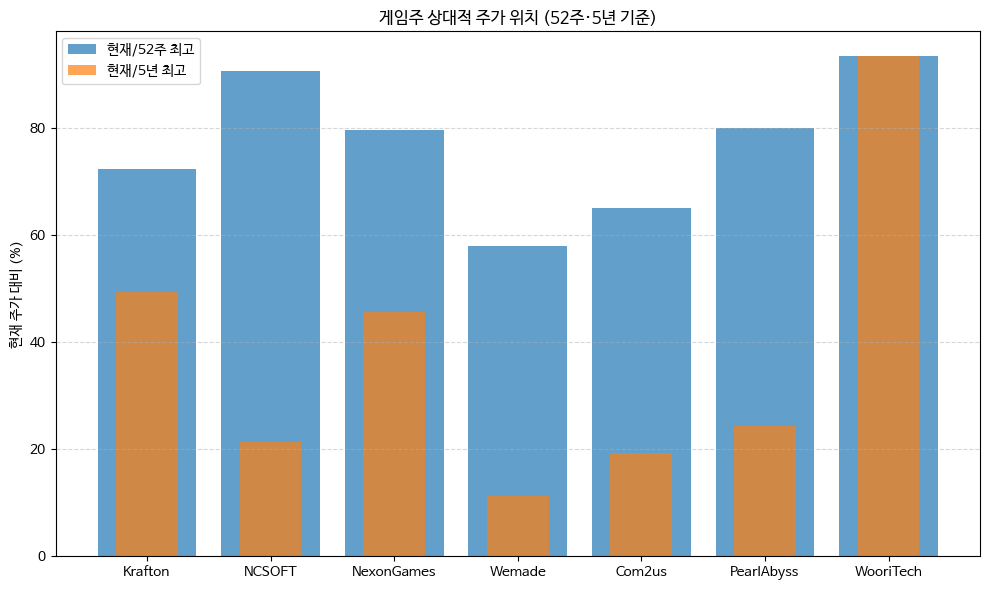

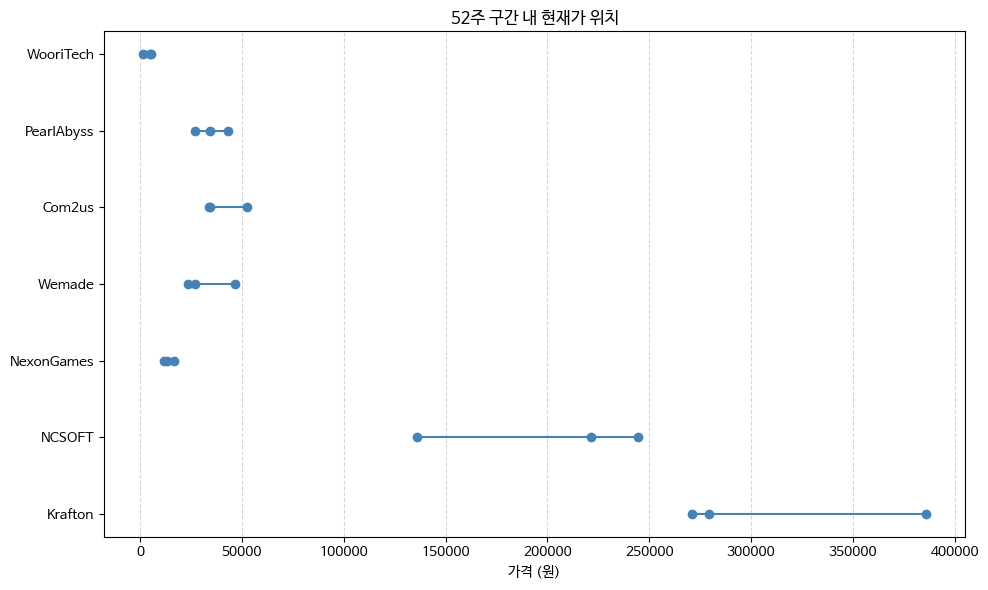

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터 (Nicole의 표 그대로 입력)
data = {
    "종목": ["Krafton","NCSOFT","NexonGames","Wemade","Com2us","PearlAbyss","WooriTech"],
    "현재가": [279500,221500,13410,26900,34200,34400,4895],
    "52주최고": [386000,244500,16840,46400,52600,42950,5240],
    "52주최저": [271000,135800,11590,23650,34000,27150,1555],
    "5년최고": [567000,1038000,29350,237000,177600,141000,5240],
    "5년최저": [146500,135800,7690,17302,34000,27000,1105]
}
df = pd.DataFrame(data)

# 비율 계산
df["현재/52주최고(%)"] = df["현재가"]/df["52주최고"]*100
df["현재/5년최고(%)"] = df["현재가"]/df["5년최고"]*100

# 시각화 스타일
plt.figure(figsize=(10,6))
plt.bar(df["종목"], df["현재/52주최고(%)"], label="현재/52주 최고", alpha=0.7)
plt.bar(df["종목"], df["현재/5년최고(%)"], label="현재/5년 최고", alpha=0.7, width=0.5)
plt.ylabel("현재 주가 대비 (%)")
plt.title("게임주 상대적 주가 위치 (52주·5년 기준)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 세부 비교선 (현재가 vs 52주 최고/최저)
fig, ax = plt.subplots(figsize=(10,6))
for i, row in df.iterrows():
    ax.plot([row["52주최저"], row["현재가"], row["52주최고"]],
            [i,i,i], marker='o', color='steelblue')
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["종목"])
ax.set_xlabel("가격 (원)")
ax.set_title("52주 구간 내 현재가 위치")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


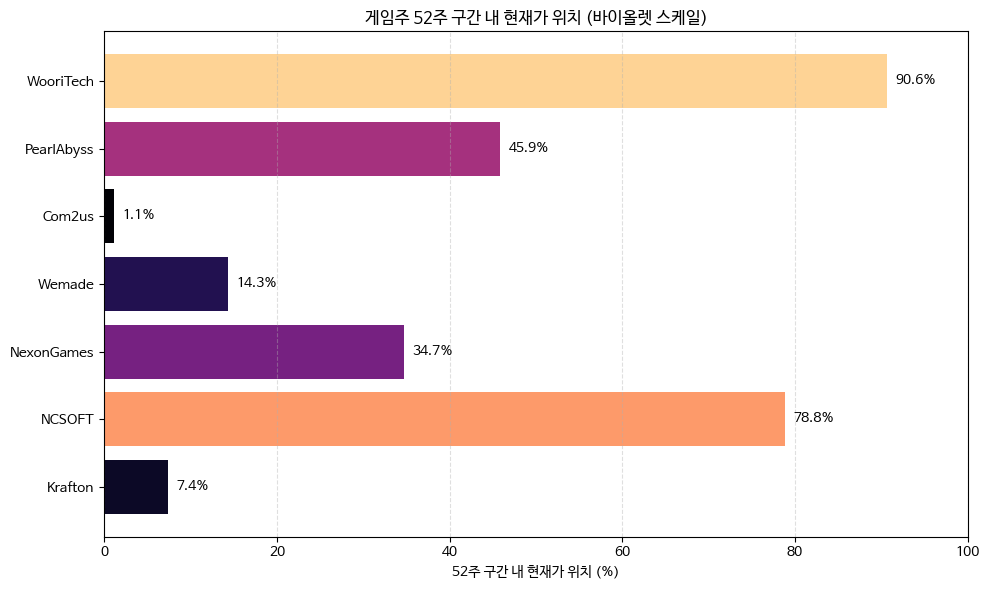

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터
data = {
    "종목": ["Krafton","NCSOFT","NexonGames","Wemade","Com2us","PearlAbyss","WooriTech"],
    "현재가": [279500,221500,13410,26900,34200,34400,4895],
    "52주최고": [386000,244500,16840,46400,52600,42950,5240],
    "52주최저": [271000,135800,11590,23650,34000,27150,1555]
}
df = pd.DataFrame(data)

# 현재가의 위치(%) 계산
df["52주내위치(%)"] = (df["현재가"] - df["52주최저"]) / (df["52주최고"] - df["52주최저"]) * 100

# 바이올렛 계열 컬러맵
plt.figure(figsize=(10,6))
bars = plt.barh(df["종목"], df["52주내위치(%)"], color=plt.cm.magma(df["52주내위치(%)"]/100))

plt.xlabel("52주 구간 내 현재가 위치 (%)")
plt.title("게임주 52주 구간 내 현재가 위치 (바이올렛 스케일)")
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.4)

# 값 표시
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}%", va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()


In [24]:
!pip install pykrx finance-datareader --quiet

import pandas as pd
from pykrx import stock
import FinanceDataReader as fdr
from datetime import datetime

# 대상 종목 티커 (한국거래소 종목코드)
tickers = {
    "Krafton":"259960",
    "NCSOFT":"036570",
    "NexonGames":"225570",
    "Wemade":"112040",
    "Com2us":"078340",
    "PearlAbyss":"263750"
}

start = "2024-01-01"
end = datetime.now().strftime("%Y-%m-%d")

result = []

for name, code in tickers.items():
    # 1️⃣ 외국인·기관·개인 순매수(주식수 기준)
    df = stock.get_market_trading_volume_by_date(start, end, code, market="KOSDAQ" if code.startswith("2") else "KOSPI")
    df = df.reset_index()
    foreign_buy = df["외국인"].sum()    # 외국인 누적 순매수 주식 수
    instit_buy = df["기관합계"].sum()
    total_flow = foreign_buy + instit_buy

    # 2️⃣ 상장주식수
    info = fdr.StockListing("KOSPI")
    if code not in info["Code"].values:
        info = pd.concat([info, fdr.StockListing("KOSDAQ")])
    shares = info.loc[info["Code"] == code, "Shares"].values[0]

    # 3️⃣ 비율 계산
    ratio = (total_flow / shares) * 100

    result.append({
        "종목": name,
        "외국인+기관 순매수(주)": total_flow,
        "총발행주식수(주)": shares,
        "유입비율(%)": ratio
    })

df_result = pd.DataFrame(result)
display(df_result)


TypeError: get_market_trading_volume_by_date() got an unexpected keyword argument 'market'

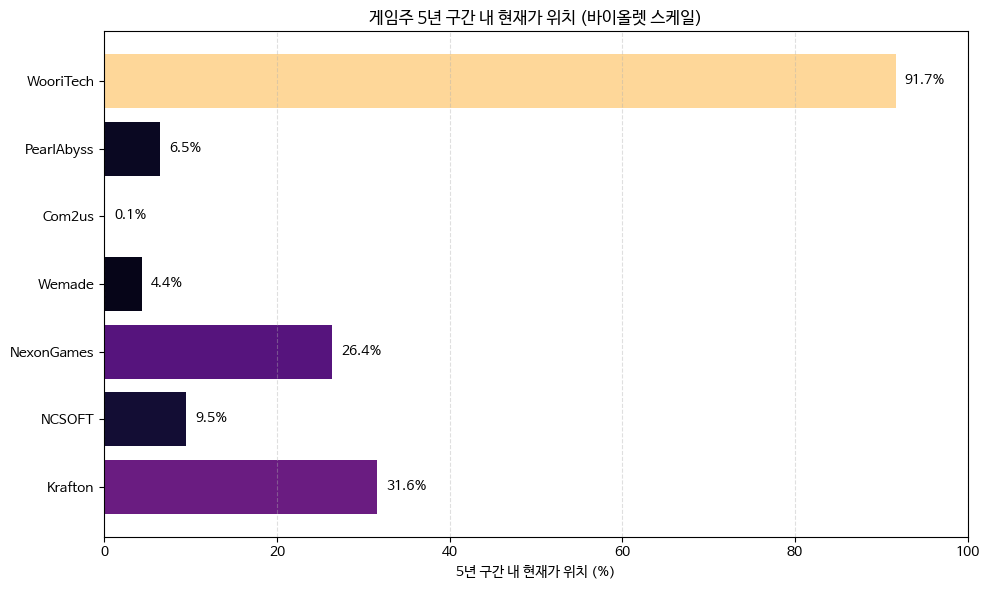

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터 (Nicole 표 기반)
data = {
    "종목": ["Krafton","NCSOFT","NexonGames","Wemade","Com2us","PearlAbyss","WooriTech"],
    "현재가": [279500,221500,13410,26900,34200,34400,4895],
    "5년최고": [567000,1038000,29350,237000,177600,141000,5240],
    "5년최저": [146500,135800,7690,17302,34000,27000,1105]
}
df = pd.DataFrame(data)

# 5년 구간 내 현재가 비율 계산
df["5년내위치(%)"] = (df["현재가"] - df["5년최저"]) / (df["5년최고"] - df["5년최저"]) * 100

# 바이올렛 계열 색상으로 시각화
plt.figure(figsize=(10,6))
bars = plt.barh(df["종목"], df["5년내위치(%)"], color=plt.cm.magma(df["5년내위치(%)"]/100))

plt.xlabel("5년 구간 내 현재가 위치 (%)")
plt.title("게임주 5년 구간 내 현재가 위치 (바이올렛 스케일)")
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.4)

# 값 표시
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}%", va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()


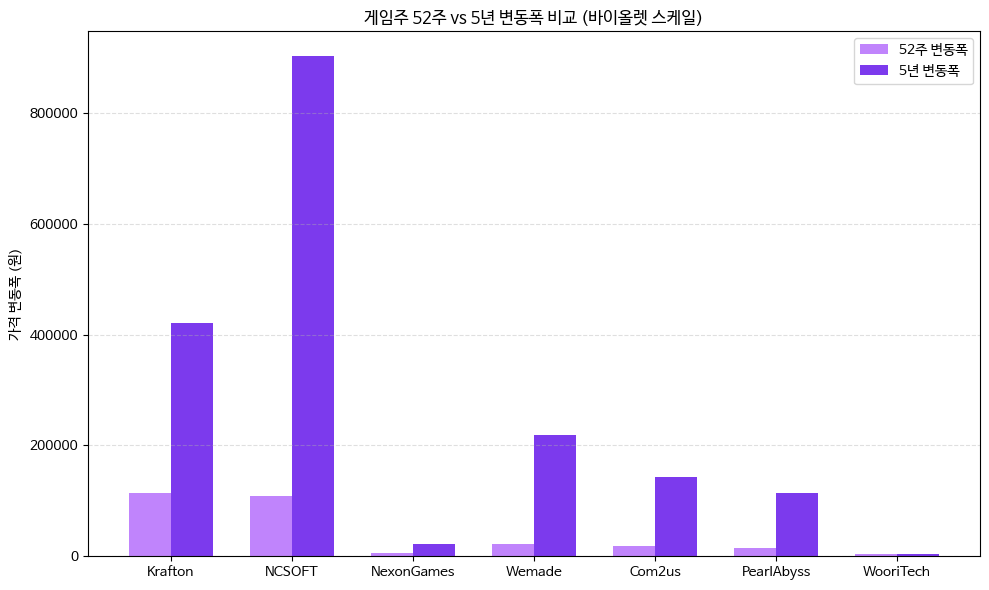

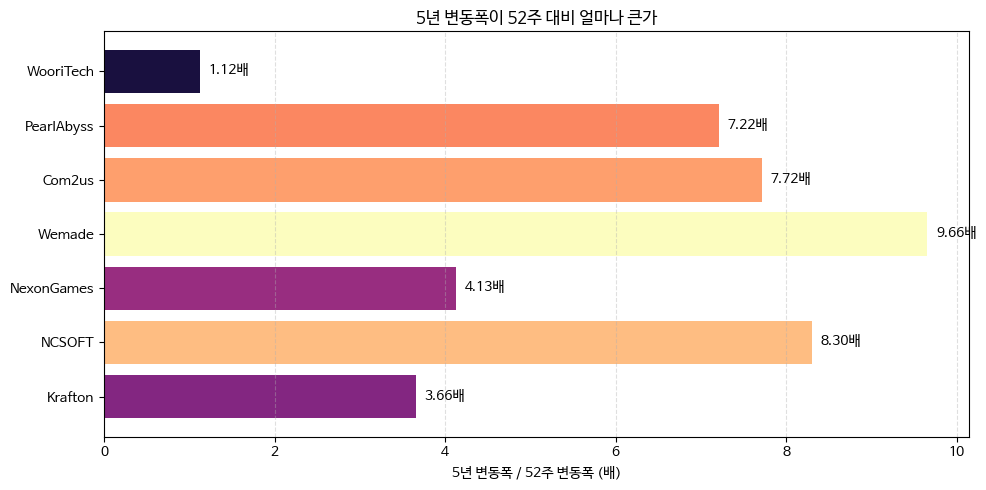

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 예시 데이터
data = {
    "종목": ["Krafton","NCSOFT","NexonGames","Wemade","Com2us","PearlAbyss","WooriTech"],
    "52주최고": [386000,244500,16840,46400,52600,42950,5240],
    "52주최저": [271000,135800,11590,23650,34000,27150,1555],
    "5년최고": [567000,1038000,29350,237000,177600,141000,5240],
    "5년최저": [146500,135800,7690,17302,34000,27000,1105]
}
df = pd.DataFrame(data)

# 각 구간별 변동폭 계산
df["52주변동폭"] = df["52주최고"] - df["52주최저"]
df["5년변동폭"] = df["5년최고"] - df["5년최저"]

# 변동폭 비율 (5년 변동폭 / 52주 변동폭)
df["변동폭비율"] = df["5년변동폭"] / df["52주변동폭"]

# 그래프 1: 5년 vs 52주 변동폭 비교 (바이올렛 스케일)
x = np.arange(len(df))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, df["52주변동폭"], width=width, label="52주 변동폭", color="#C084FC")
plt.bar(x + width/2, df["5년변동폭"], width=width, label="5년 변동폭", color="#7C3AED")

plt.xticks(x, df["종목"])
plt.ylabel("가격 변동폭 (원)")
plt.title("게임주 52주 vs 5년 변동폭 비교 (바이올렛 스케일)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 그래프 2: 변동폭 비율 시각화 (5년 변동폭이 몇 배 큰가)
plt.figure(figsize=(10,5))
bars = plt.barh(df["종목"], df["변동폭비율"], color=plt.cm.magma(df["변동폭비율"]/df["변동폭비율"].max()))
plt.xlabel("5년 변동폭 / 52주 변동폭 (배)")
plt.title("5년 변동폭이 52주 대비 얼마나 큰가")
plt.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}배", va='center', ha='left')

plt.tight_layout()
plt.show()


In [13]:
# 코스닥 누적 순매수 상위기업 리스트업 (대통령 이후 ~ 오늘)
!pip install pykrx finance-datareader --quiet

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pykrx import stock

# === 파라미터 ===
START = "2022-05-10"   # 대통령 취임일 등 시작일(YYYY-MM-DD)로 변경 가능
END   = datetime.now().strftime("%Y-%m-%d")
TARGET_MARKET = "KOSDAQ"
INVESTORS = ["외국인", "기관합계", "연기금", "개인"]  # 원하는 주체만 남기세요
TOPK = 30

# === 거래일 생성 ===
def get_trading_days(start, end):
    # KRX 영업일만 추출
    days = stock.get_market_ohlcv_by_date(start, end, "005930").index
    return [d.strftime("%Y%m%d") for d in days]

days = get_trading_days(START, END)

# === 티커/종목명 ===
tickers = stock.get_market_ticker_list(market=TARGET_MARKET, date=days[-1])
name_map = {t: stock.get_market_ticker_name(t) for t in tickers}

# === 누적 순매수 집계 ===
agg = {inv: {} for inv in INVESTORS}

for d in days:
    # 일자별 코스닥 전 종목 '투자자별 순매수(거래대금)' 테이블
    df = stock.get_market_trading_value_by_ticker(d, market=TARGET_MARKET)
    # 컬럼 표준화(연기금 표기 이슈 호환)
    colmap = {c:c for c in df.columns}
    for candidate in ["연기금", "연기금등", "연기금등기금"]:
        if candidate in df.columns:
            colmap[candidate] = "연기금"
    df = df.rename(columns=colmap)
    # 필요한 주체만 필터
    cols = [c for c in INVESTORS if c in df.columns]
    if not cols:
        continue
    # 순매수 금액(억원 기준) 누적 더하기
    for inv in cols:
        s = df[inv].astype(float)
        for t, v in s.items():
            if t not in agg[inv]:
                agg[inv][t] = 0.0
            # pykrx 값 단위가 "백만원"일 수 있어 안전 스케일 조정 옵션(필요시 주석 해제)
            # v = v / 100.0
            agg[inv][t] += v

# === 주체별 상위표 생성 ===
tables = {}
for inv in INVESTORS:
    data = agg.get(inv, {})
    if not data:
        continue
    tmp = pd.DataFrame.from_dict(data, orient="index", columns=[f"{inv}_누적순매수"])
    tmp.index.name = "티커"
    tmp["종목명"] = tmp.index.map(name_map)
    tmp = tmp.reset_index()[["티커","종목명",f"{inv}_누적순매수"]]
    tmp = tmp.sort_values(f"{inv}_누적순매수", ascending=False).head(TOPK)
    tables[inv] = tmp

# === 통합 테이블(선택): 주체별 누적을 한 표에 병합 & 총합 기준 랭킹 ===
merged = None
for inv, df in tables.items():
    col = f"{inv}_누적순매수"
    part = df[["티커", col]]
    if merged is None:
        merged = df[["티커","종목명", col]].copy()
    else:
        merged = pd.merge(merged, part, on="티커", how="outer")

if merged is not None:
    for inv in INVESTORS:
        col = f"{inv}_누적순매수"
        if col not in merged.columns:
            merged[col] = np.nan
    merged["누적합계"] = merged[[f"{inv}_누적순매수" for inv in INVESTORS if f"{inv}_누적순매수" in merged.columns]].sum(axis=1, skipna=True)
    merged = merged.sort_values("누적합계", ascending=False).head(TOPK).reset_index(drop=True)

# === 출력 ===
print(f"[기간] {START} ~ {END} / 시장: {TARGET_MARKET}")
for inv, df in tables.items():
    print(f"\n◆ {inv} 누적 순매수 상위 {TOPK}")
    display(df.reset_index(drop=True))

if merged is not None:
    print("\n◆ 주체 합산 누적 순매수 상위 (통합 랭킹)")
    display(merged.reset_index(drop=True))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 23.5 MB/s eta 0:00:00


AttributeError: module 'pykrx.stock' has no attribute 'get_market_trading_value_by_ticker'


외국인 순매수 상위 10


,티커,외국인_누적순매수,종목명



기관합계 순매수 상위 10


,티커,기관합계_누적순매수,종목명
0,2022-11-11,3.430423e+11,NaN
1,2022-12-27,2.983333e+11,NaN
2,2023-12-14,2.949099e+11,NaN
3,2023-07-27,2.665778e+11,NaN
4,2023-02-07,2.451700e+11,NaN
5,2022-12-01,2.407162e+11,NaN
6,2023-10-24,2.377738e+11,NaN
7,2022-09-13,2.277559e+11,NaN
8,2022-12-26,2.252597e+11,NaN
9,2024-11-04,2.071012e+11,NaN



연기금 순매수 상위 10


,티커,연기금_누적순매수,종목명



개인 순매수 상위 10


,티커,개인_누적순매수,종목명
0,2022-12-28,5.915313e+11,NaN
1,2023-06-14,5.644751e+11,NaN
2,2023-08-02,5.563754e+11,NaN
3,2023-04-10,5.490578e+11,NaN
4,2023-02-22,5.241720e+11,NaN
5,2024-01-29,5.185302e+11,NaN
6,2023-03-14,5.011020e+11,NaN
7,2023-04-20,4.812570e+11,NaN
8,2024-04-02,4.768745e+11,NaN
9,2023-11-07,4.672606e+11,NaN



통합 누적 순매수 상위


,티커,종목명,외국인_누적순매수,기관합계_누적순매수,연기금_누적순매수,개인_누적순매수,누적합계
0,2022-12-28,NaN,NaN,NaN,NaN,5.915313e+11,591531272973.0
1,2023-06-14,NaN,NaN,NaN,NaN,5.644751e+11,564475079430.0
2,2023-08-02,NaN,NaN,NaN,NaN,5.563754e+11,556375360430.0
3,2023-04-10,NaN,NaN,NaN,NaN,5.490578e+11,549057784736.0
4,2023-02-22,NaN,NaN,NaN,NaN,5.241720e+11,524172022652.0
5,2024-01-29,NaN,NaN,NaN,NaN,5.185302e+11,518530161902.0
6,2023-03-14,NaN,NaN,NaN,NaN,5.011020e+11,501102043139.0
7,2023-04-20,NaN,NaN,NaN,NaN,4.812570e+11,481256956737.0
8,2024-04-02,NaN,NaN,NaN,NaN,4.768745e+11,476874508635.0
9,2023-11-07,NaN,NaN,NaN,NaN,4.672606e+11,467260603988.0


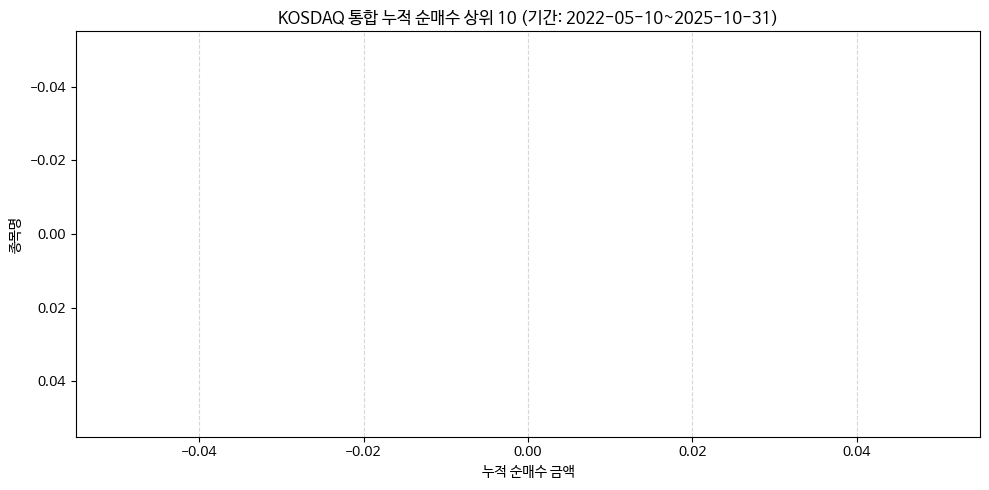

from matplotlib import pyplot as plt
merged['개인_누적순매수'].plot(kind='hist', bins=20, title='개인_누적순매수')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['티커']
  ys = series['개인_누적순매수']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = merged.sort_values('티커', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('티커')
_ = plt.ylabel('개인_누적순매수')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['티커']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': '티커'}, axis=1)
              .sort_values('티커', ascending=True))
  xs = counted['티커']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = merged.sort_values('티커', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('티커')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
merged['개인_누적순매수'].plot(kind='line', figsize=(8, 4), title='개인_누적순매수')
plt.gca().spines[['top', 'right']].set_visible(False)

In [16]:
!pip install pykrx matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pykrx import stock

START = "2022-05-10"
END = datetime.now().strftime("%Y-%m-%d")
MARKET = "KOSDAQ"
INVESTORS = ["외국인", "기관합계", "연기금", "개인"]
TOPK = 10

dates = stock.get_market_ohlcv_by_date(START, END, "005930").index.strftime("%Y%m%d").tolist()
tickers = stock.get_market_ticker_list(market=MARKET, date=dates[-1])
name_map = {t: stock.get_market_ticker_name(t) for t in tickers}
agg = {inv: {} for inv in INVESTORS}

for d in dates:
    df = stock.get_market_trading_value_by_date(d, d, MARKET)  # market 인자 제거, 문자열 직접 전달
    if "합계" in df.columns:
        df = df.iloc[:, :-1]
    for alt in ["연기금", "연기금등", "연기금등기금"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "연기금"})
    cols = [c for c in INVESTORS if c in df.columns]
    for inv in cols:
        for code, val in df[inv].astype(float).items():
            agg[inv][code] = agg[inv].get(code, 0.0) + val

tables = {}
for inv in INVESTORS:
    s = pd.Series(agg[inv], name=f"{inv}_누적순매수")
    df = s.reset_index().rename(columns={"index": "티커"})
    df["종목명"] = df["티커"].map(name_map)
    df = df.sort_values(by=f"{inv}_누적순매수", ascending=False).head(TOPK)
    tables[inv] = df

merged = None
for inv, df in tables.items():
    col = f"{inv}_누적순매수"
    part = df[["티커", col]]
    if merged is None:
        merged = df[["티커", "종목명", col]].copy()
    else:
        merged = pd.merge(merged, part, on="티커", how="outer")

if merged is not None:
    for inv in INVESTORS:
        col = f"{inv}_누적순매수"
        if col not in merged.columns:
            merged[col] = np.nan
    merged["누적합계"] = merged[[f"{inv}_누적순매수" for inv in INVESTORS]].sum(axis=1)
    merged = merged.sort_values("누적합계", ascending=False).head(TOPK).reset_index(drop=True)

for inv, df in tables.items():
    print(f"\n{inv} 순매수 상위 {TOPK}")
    display(df.reset_index(drop=True))

print("\n통합 누적 순매수 상위")
display(merged)

plt.figure(figsize=(10, 5))
plt.barh(merged["종목명"], merged["누적합계"], color="steelblue")
plt.xlabel("누적 순매수 금액")
plt.ylabel("종목명")
plt.title(f"{MARKET} 통합 누적 순매수 상위 {TOPK} (기간: {START}~{END})")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


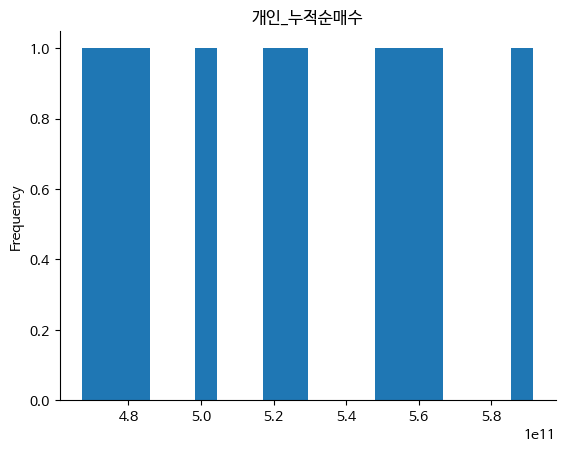

In [17]:
from matplotlib import pyplot as plt
merged['개인_누적순매수'].plot(kind='hist', bins=20, title='개인_누적순매수')
plt.gca().spines[['top', 'right',]].set_visible(False)

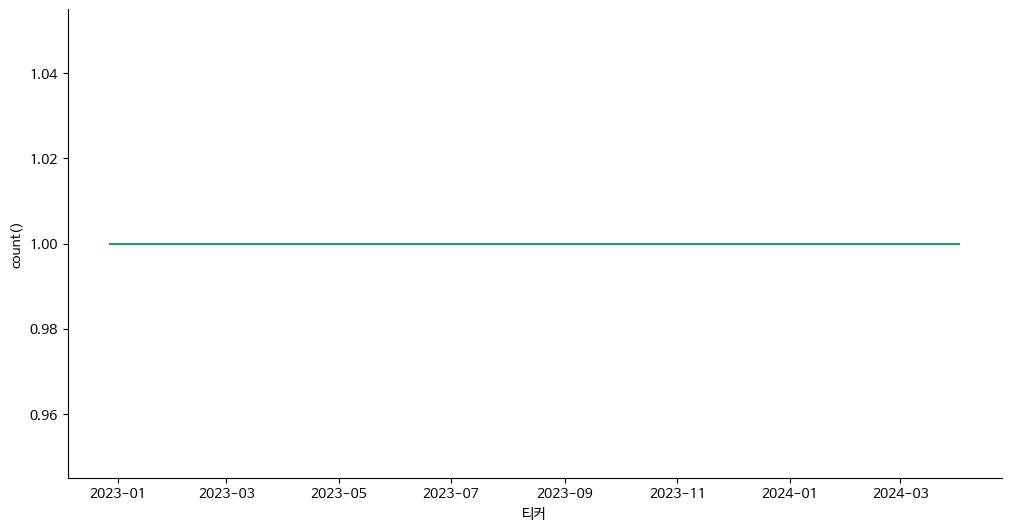

In [18]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['티커']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': '티커'}, axis=1)
              .sort_values('티커', ascending=True))
  xs = counted['티커']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = merged.sort_values('티커', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('티커')
_ = plt.ylabel('count()')

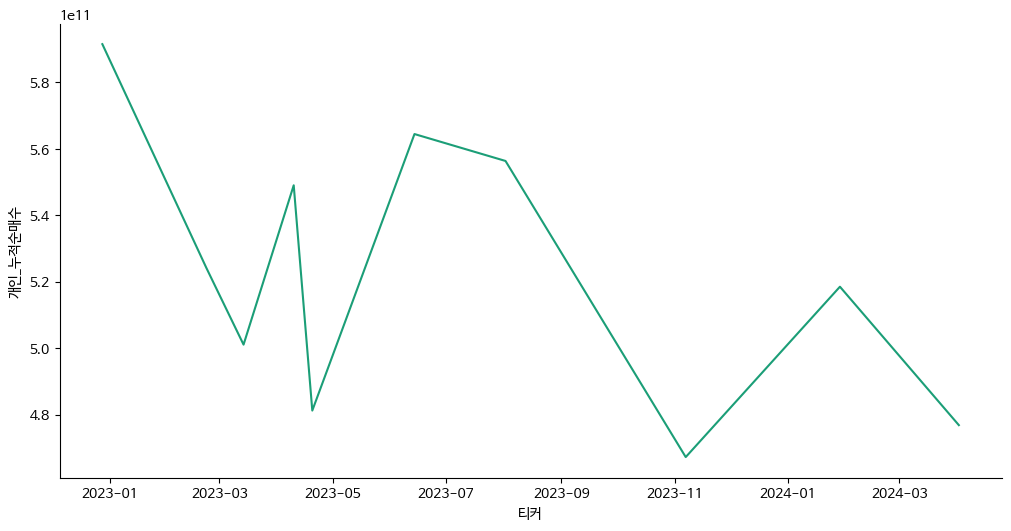

In [19]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['티커']
  ys = series['개인_누적순매수']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = merged.sort_values('티커', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('티커')
_ = plt.ylabel('개인_누적순매수')

In [ ]:
from matplotlib import pyplot as plt
merged['개인_누적순매수'].plot(kind='line', figsize=(8, 4), title='개인_누적순매수')
plt.gca().spines[['top', 'right']].set_visible(False)